# 29 — Trace one trade through the complete calculation

Follow corporate bond C02 from trade terms through pricing, sensitivities and default risk.

One foreign corporate bond creates GIRR, CSR and FX sensitivities in SBM and jump-to-default exposure in DRC. The trade identifier links every stage.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns, display_sample,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260908T033903126517Z


This is the part of the calculation chain being handled here:

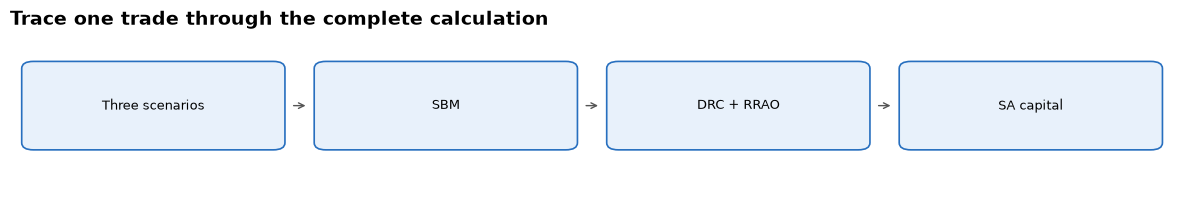

In [2]:
draw_flow(['Three scenarios', 'SBM', 'DRC + RRAO', 'SA capital'],'Trace one trade through the complete calculation',wrap_after=4)

Display each stage separately so unlike columns are not forced into one unreadable table.

$$C02\rightarrow\text{price}\rightarrow\{GIRR,CSR,FX\}\rightarrow SBM$$

$$C02\rightarrow JTD\rightarrow DRC$$

In [3]:
trade=pd.read_csv(RUN/'01_trades.csv').query("trade_id=='C02'")
valuation=pd.read_csv(RUN/'02_valuations.csv').query("trade_id=='C02'")
delta=pd.read_csv(RUN/'03_delta_trade_level.csv').query("trade_id=='C02'").copy()
jtd=pd.read_csv(RUN/'11_drc_gross_jtd.csv').query("trade_id=='C02'")
print('1. Original trade terms'); display(trade[['trade_id','desk','instrument_type','currency','notional','long_short','underlying','rating','maturity_years']])
print('2. Base valuation'); display(crore_table(valuation[['trade_id','market_value_local','fx_to_inr','market_value_inr']],['market_value_inr']))
print('3. Separate SBM sensitivity rows'); delta['bump_effect_inr']=delta.shocked_value_inr-delta.base_value_inr
display(crore_table(delta[['risk_class','bucket','risk_factor_id','shock_size','bump_effect_inr','raw_sensitivity']],['bump_effect_inr','raw_sensitivity']))
print('4. DRC gross JTD row')
jtd_display=jtd.dropna(axis=1,how='all').fillna('Not applicable')
display(percent_columns(crore_table(jtd_display,['gross_jtd']),['risk_weight']))

1. Original trade terms


,trade_id,desk,instrument_type,currency,notional,long_short,underlying,rating,maturity_years
13,C02,Credit,CORPORATE_BOND,USD,1500000,long,US_INDUSTRIAL,BBB,7.0000


2. Base valuation


,trade_id,market_value_local,fx_to_inr,Market Value (INR crore)
13,C02,"1,445,713.9595",86.2000,12.4621


3. Separate SBM sensitivity rows


,risk_class,bucket,risk_factor_id,shock_size,Bump Effect (INR crore),Raw Sensitivity (INR crore per unit change)
22,GIRR,USD,USD_OIS_5.0Y,0.0001,-0.0045,-44.6603
23,GIRR,USD,USD_OIS_10.0Y,0.0001,-0.0030,-29.7755
24,CSR_NON_SECURITISATION,4,US_INDUSTRIAL_5.0Y,0.0001,-0.0045,-44.6603
25,CSR_NON_SECURITISATION,4,US_INDUSTRIAL_10.0Y,0.0001,-0.0030,-29.7755
26,FX,USD,USDINR,0.0100,0.1246,12.4621


4. DRC gross JTD row


,trade_id,drc_class,bucket,obligor,rating,seniority,maturity_scale,lgd,Gross Jtd (INR crore),Risk Weight (%)
7,C02,NON_SECURITISATION,CORPORATE,US_INDUSTRIAL,BBB,SENIOR,1.0000,0.7500,9.2296,6.0000


The visual below uses the calculated rows shown above.

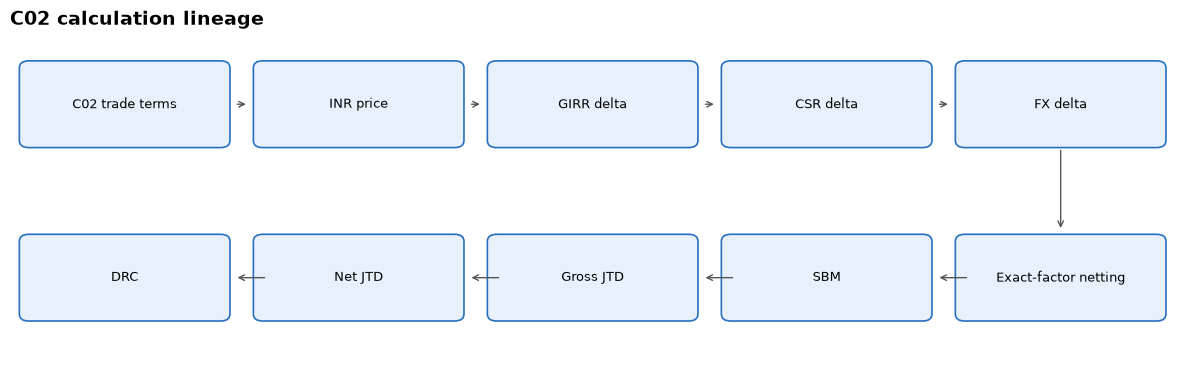

In [4]:
draw_flow(['C02 trade terms','INR price','GIRR delta','CSR delta','FX delta','Exact-factor netting','SBM','Gross JTD','Net JTD','DRC'],'C02 calculation lineage',wrap_after=5)

Every portfolio result can be traced back to identifiable trades, inputs and transformations.